# Importing required packages and creating dataset
## Using only cropped training set

In [ ]:
# Dataset import
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy

from PIL import Image

import random

def create_df(path):
    dd = {"images": [], "labels": []}
    for i in os.listdir(path):
        img_dir = os.path.join(path, i)
        dirs = os.listdir(img_dir)
        index = 0
        for j in dirs:
            dd["images"] += [os.path.join(img_dir, j)]
            dd["labels"] += [i]
            index += 1
            if index == 1000:
                break

    return pd.DataFrame(dd)

df = create_df("/kaggle/input/brain-tumor-mri-dataset/Training")

index_label = dict()
label_index = dict()

for i, j in enumerate(df["labels"].unique()):
    index_label[i] = j
    label_index[j] = i

df["labels"] = df["labels"].map(label_index)

In [3]:
!ls /kaggle/input/brain-tumor-mri-dataset/Training/glioma

Tr-gl_1000.jpg	Tr-gl_1253.jpg	Tr-gl_244.jpg  Tr-gl_497.jpg  Tr-gl_749.jpg
Tr-gl_1001.jpg	Tr-gl_1254.jpg	Tr-gl_245.jpg  Tr-gl_498.jpg  Tr-gl_74.jpg
Tr-gl_1002.jpg	Tr-gl_1255.jpg	Tr-gl_246.jpg  Tr-gl_499.jpg  Tr-gl_750.jpg
Tr-gl_1003.jpg	Tr-gl_1256.jpg	Tr-gl_247.jpg  Tr-gl_49.jpg   Tr-gl_751.jpg
Tr-gl_1004.jpg	Tr-gl_1257.jpg	Tr-gl_248.jpg  Tr-gl_4.jpg    Tr-gl_752.jpg
Tr-gl_1005.jpg	Tr-gl_1258.jpg	Tr-gl_249.jpg  Tr-gl_500.jpg  Tr-gl_753.jpg
Tr-gl_1006.jpg	Tr-gl_1259.jpg	Tr-gl_24.jpg   Tr-gl_501.jpg  Tr-gl_754.jpg
Tr-gl_1007.jpg	Tr-gl_125.jpg	Tr-gl_250.jpg  Tr-gl_502.jpg  Tr-gl_755.jpg
Tr-gl_1008.jpg	Tr-gl_1260.jpg	Tr-gl_251.jpg  Tr-gl_503.jpg  Tr-gl_756.jpg
Tr-gl_1009.jpg	Tr-gl_1261.jpg	Tr-gl_252.jpg  Tr-gl_504.jpg  Tr-gl_757.jpg
Tr-gl_100.jpg	Tr-gl_1262.jpg	Tr-gl_253.jpg  Tr-gl_505.jpg  Tr-gl_758.jpg
Tr-gl_1010.jpg	Tr-gl_1263.jpg	Tr-gl_254.jpg  Tr-gl_506.jpg  Tr-gl_759.jpg
Tr-gl_1011.jpg	Tr-gl_1264.jpg	Tr-gl_255.jpg  Tr-gl_507.jpg  Tr-gl_75.jpg
Tr-gl_1012.jpg	Tr-gl_1265.jpg	Tr-gl_256.jp

# Downloading ResNet and setting up training environment

In [4]:
EPOCHS = 10
STEP = 10
LR = 0.1
GAMMA = 0.1
IMG_SIZE = 224
BATCH = 16
OUT_SIZE = len(index_label)

class Pipeline(Dataset):
    def __init__(self, data, transform):
        super(Pipeline, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):

        img, label = self.data[x, 0], self.data[x, 1]

        img = Image.open(img).convert("RGB")
        img = np.array(img)

        img = self.transform(img)
        return img, label

transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

train, val = train_test_split(df.values, random_state=42, test_size=0.25)
test, val = train_test_split(val, random_state=42, test_size=0.5)

train_ds = Pipeline(train, transform)
val_ds = Pipeline(val, transform)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, OUT_SIZE)

class ResNet(nn.Module):
    def __init__(self, model):
        super(ResNet, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResNet(resnet)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


# Fine-tuning process log results

Epoch 1 train loss 0.052184861540794374 acc 0.913 val loss 0.05386602282524109 acc 0.91
Epoch 2 train loss 0.04969737442334493 acc 0.953 val loss 0.0508877215385437 acc 0.95
Epoch 3 train loss 0.04885680325826009 acc 0.966 val loss 0.05131070256233215 acc 0.952
Epoch 4 train loss 0.048130687991778054 acc 0.9766666666666667 val loss 0.051866412520408633 acc 0.934
Epoch 5 train loss 0.04779181921482086 acc 0.9833333333333333 val loss 0.05024518620967865 acc 0.97
Epoch 6 train loss 0.04700539529323578 acc 0.9956666666666667 val loss 0.05053323757648468 acc 0.962
Epoch 7 train loss 0.047311061044534045 acc 0.99 val loss 0.05144696962833405 acc 0.948
Epoch 8 train loss 0.04714713509877523 acc 0.9926666666666667 val loss 0.05125823855400086 acc 0.948
Epoch 9 train loss 0.047191509942213695 acc 0.993 val loss 0.05046499562263489 acc 0.96
Epoch 10 train loss 0.04692684547106425 acc 0.9966666666666667 val loss 0.04958848738670349 acc 0.974


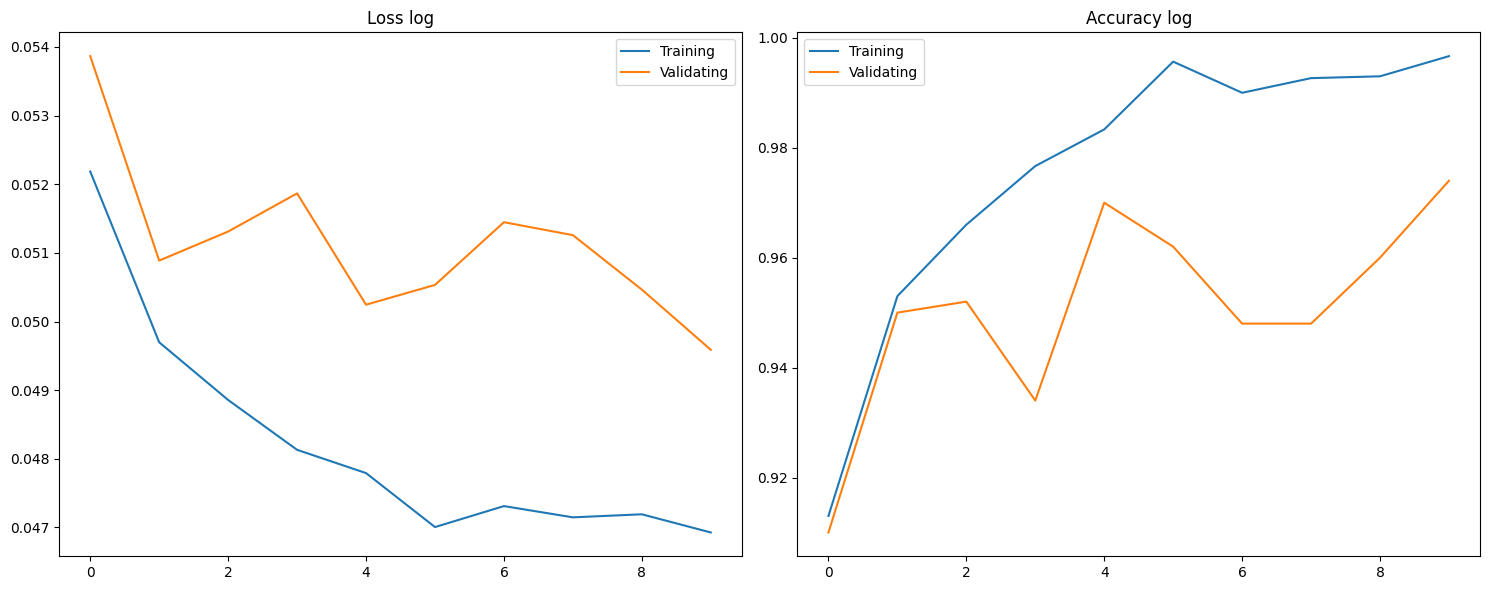

In [6]:
best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_acc = []
val_loss = []

for i in range(1, EPOCHS+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out = model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out = model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)

    scheduler.step()

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

# Fine-tuned ResNet50 inference results

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       129
           1       0.96      0.98      0.97       123
           2       0.98      0.96      0.97       135
           3       0.97      0.98      0.98       113

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



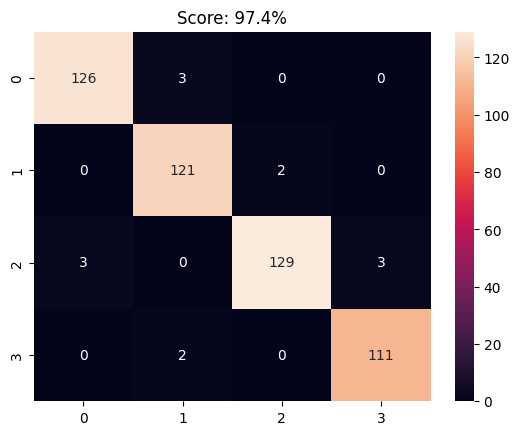

In [7]:
def predict(img):
    img = Image.open(img).convert("RGB")
    img = transform(np.array(img))
    img = img.view([1, 3, 224, 224])

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            img = img.cuda()
        out = best_model(img)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)

truth = []
preds = []
probas = []

np.random.shuffle(test)

for i in range(test.shape[0]):
    truth += [test[i, 1]]
    pred, proba = predict(test[i, 0])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()